##Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


##Load the data

In [3]:
df=pd.read_csv('/content/player_stats.csv', encoding='latin1')

##Basic data anlysis

In [4]:
df.shape

(5682, 41)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
height,5682.0,181.670539,6.829238,156.0,177.0,182.0,186.0,204.0
weight,5682.0,75.282295,6.998971,54.0,70.0,75.0,80.0,102.0
age,5682.0,26.316262,4.729967,17.0,23.0,26.0,30.0,41.0
ball_control,5682.0,58.912179,16.567068,8.0,55.0,63.0,69.0,94.0
dribbling,5682.0,56.128476,18.772075,5.0,51.0,62.0,68.0,95.0
marking,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slide_tackle,5682.0,46.728441,20.519430,7.0,27.0,54.0,64.0,87.0
stand_tackle,5682.0,48.820838,20.975966,7.0,30.0,57.0,66.0,91.0
aggression,5682.0,56.324006,16.846410,11.0,45.0,60.0,69.0,96.0
reactions,5682.0,61.959345,8.893309,32.0,56.0,62.0,68.0,93.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [7]:
df

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000


##Remove the unique columns

In [8]:
df.drop('player', axis=1, inplace=True)

##Clean the data

In [9]:
def clean_value(x):
    x = str(x)
    x = x.replace('$', '').replace('.', '').strip()
    return float(x)

df['value'] = df['value'].apply(clean_value)

#Handle the null values

In [10]:
df.isnull().sum()

,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0
stand_tackle,0


In the dataset the in column of "Marking" their are the null values therefore we have to handle the null values

In [11]:
df['marking'].isnull().sum() == len(df)

np.True_

In [12]:
df = df.dropna(axis=1, how='all')

In the "marking" all the values are null in the column therefore the column is not usefull in the model building that why we remove the column by the confirming the column has null values

In [13]:
df.isnull().sum()

,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
slide_tackle,0
stand_tackle,0
aggression,0


There is no null values in the dataset

##Handle the duplicate values

In [14]:
df.duplicated().sum()

np.int64(3)

In [15]:
df.drop_duplicates(inplace=True)

We find the 3 duplicated data and drop it

In [16]:
df.shape

(5679, 39)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5679 entries, 0 to 5681
Data columns (total 39 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         5679 non-null   object 
 1   height          5679 non-null   int64  
 2   weight          5679 non-null   int64  
 3   age             5679 non-null   int64  
 4   club            5679 non-null   object 
 5   ball_control    5679 non-null   int64  
 6   dribbling       5679 non-null   int64  
 7   slide_tackle    5679 non-null   int64  
 8   stand_tackle    5679 non-null   int64  
 9   aggression      5679 non-null   int64  
 10  reactions       5679 non-null   int64  
 11  att_position    5679 non-null   int64  
 12  interceptions   5679 non-null   int64  
 13  vision          5679 non-null   int64  
 14  composure       5679 non-null   int64  
 15  crossing        5679 non-null   int64  
 16  short_pass      5679 non-null   int64  
 17  long_pass       5679 non-null   int64 

##Divide the columns into the categorical and numerical columns

In [18]:
## split the data into the categorical and numerical data

categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [19]:
categorical_columns

Index(['country', 'club'], dtype='object')

In [20]:
numerical_columns

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle',
       'stand_tackle', 'aggression', 'reactions', 'att_position',
       'interceptions', 'vision', 'composure', 'crossing', 'short_pass',
       'long_pass', 'acceleration', 'stamina', 'strength', 'balance',
       'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power',
       'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys',
       'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

##Convert the categorical_columns into the numerical data

In [21]:
from sklearn.preprocessing import LabelEncoder





In [22]:
le = LabelEncoder()

In [23]:
df['country'] = le.fit_transform(df['country'])
df['club'] = le.fit_transform(df['club'])

In [24]:
df

,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,24,192,84,22,63,55,43,68,73,72,...,32,34,41,33,10,11,6,7,9,1400000.0
1,14,181,80,31,154,69,70,56,58,62,...,65,62,48,46,12,15,14,8,14,97500.0
2,47,193,84,29,315,25,12,13,16,27,...,20,15,26,16,64,74,65,68,74,1100000.0
3,8,187,86,33,535,46,48,66,69,71,...,25,13,22,19,10,10,8,14,9,65000.0
4,130,191,80,23,330,14,8,14,16,28,...,9,10,16,5,61,59,62,64,64,30000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,37,175,71,31,383,86,88,41,43,63,...,84,69,86,83,11,14,14,9,14,99500000.0
5678,107,174,69,31,210,86,88,38,42,75,...,77,64,75,75,7,10,10,15,14,101000000.0
5679,14,175,68,31,454,94,95,29,32,63,...,88,87,91,86,15,9,9,15,11,99500000.0
5680,100,187,83,38,35,87,81,24,32,62,...,79,75,90,85,14,7,11,15,11,31000000.0


There are the only two categorical column we convert it into the numerical by the use of the label encoding

In [25]:
df.shape

(5679, 39)

##Find and remove the Outliers

In [26]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1


df=df[~((df < (Q1-1.5*IQR)) |(df> (Q3+1.5*IQR))).any(axis=1)]

In [27]:
df.shape

(4272, 39)

##Univariate Analysis

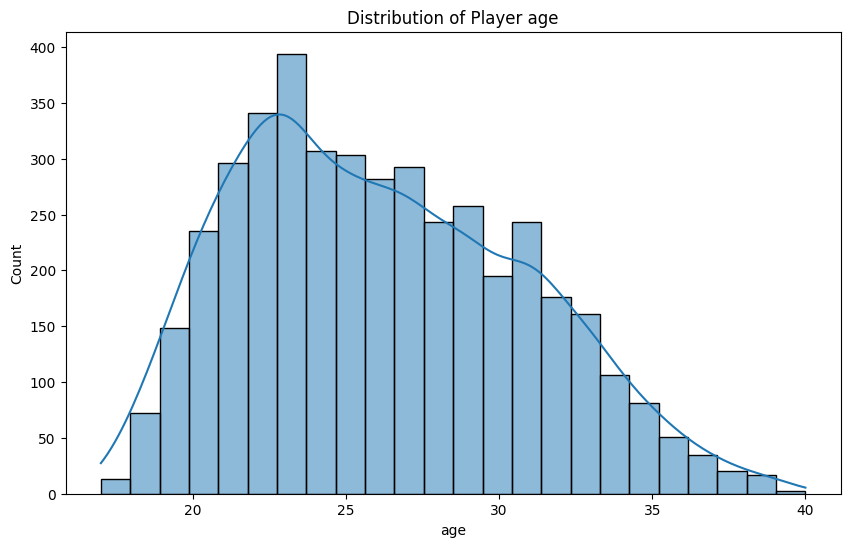

In [28]:


plt.figure(figsize=(10,6))

sns.histplot(df['age'], kde=True)


plt.title("Distribution of Player age")
plt.show()

Most players fall within the age range of 20–30 years

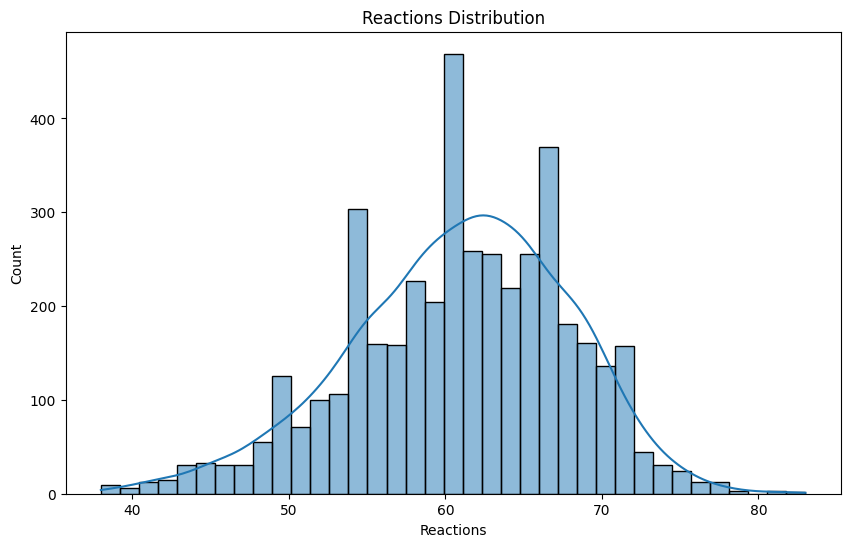

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df['reactions'], kde=True)
plt.title("Reactions Distribution")
plt.xlabel("Reactions")

plt.show()

Most of the players have the mid range reactions and the few have the extrmely high and low reactions

##Bivariate analysis

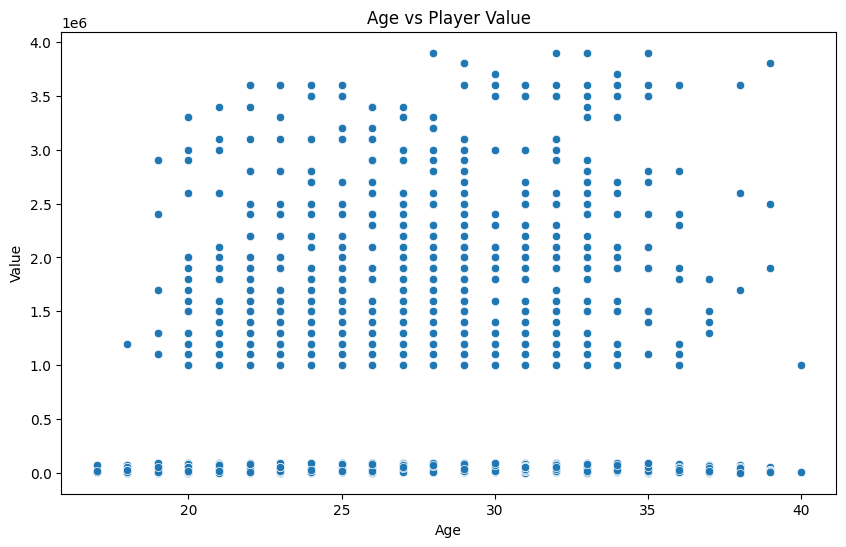

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['age'], y=df['value'])
plt.title("Age vs Player Value")
plt.xlabel("Age")
plt.ylabel("Value")
plt.show()

Player value increases up to the mid-20s and then declines indicating peak performance age after the 30 it will be decrease

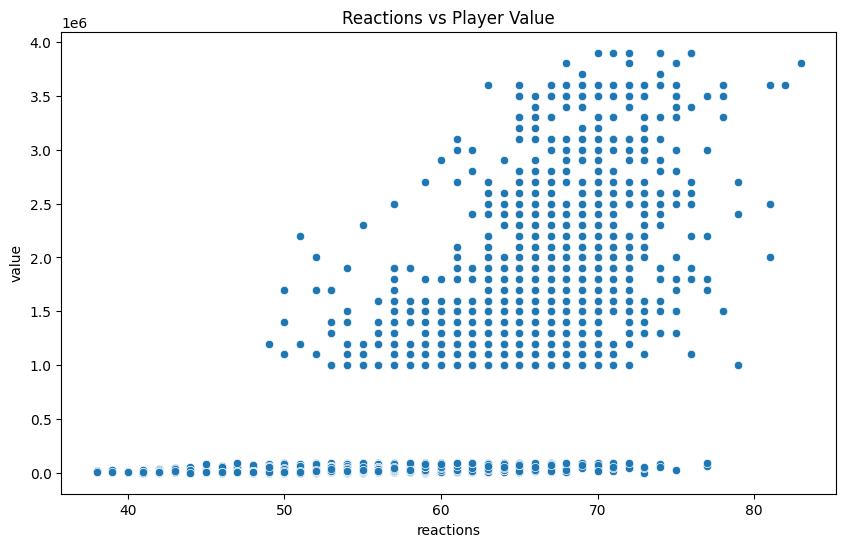

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['reactions'], y=df['value'])
plt.title("Reactions vs Player Value")
plt.show()

Players with higher reaction scores tend to have higher market value, showing a strong positive relationship

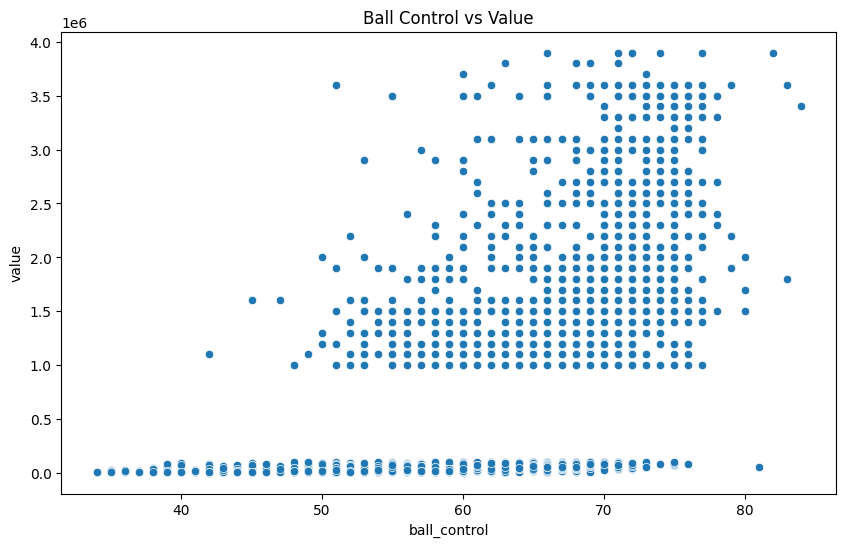

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['ball_control'], y=df['value'])
plt.title("Ball Control vs Value")
plt.show()

Better ball control is associated with higher player value, especially for midfielders and attackers.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

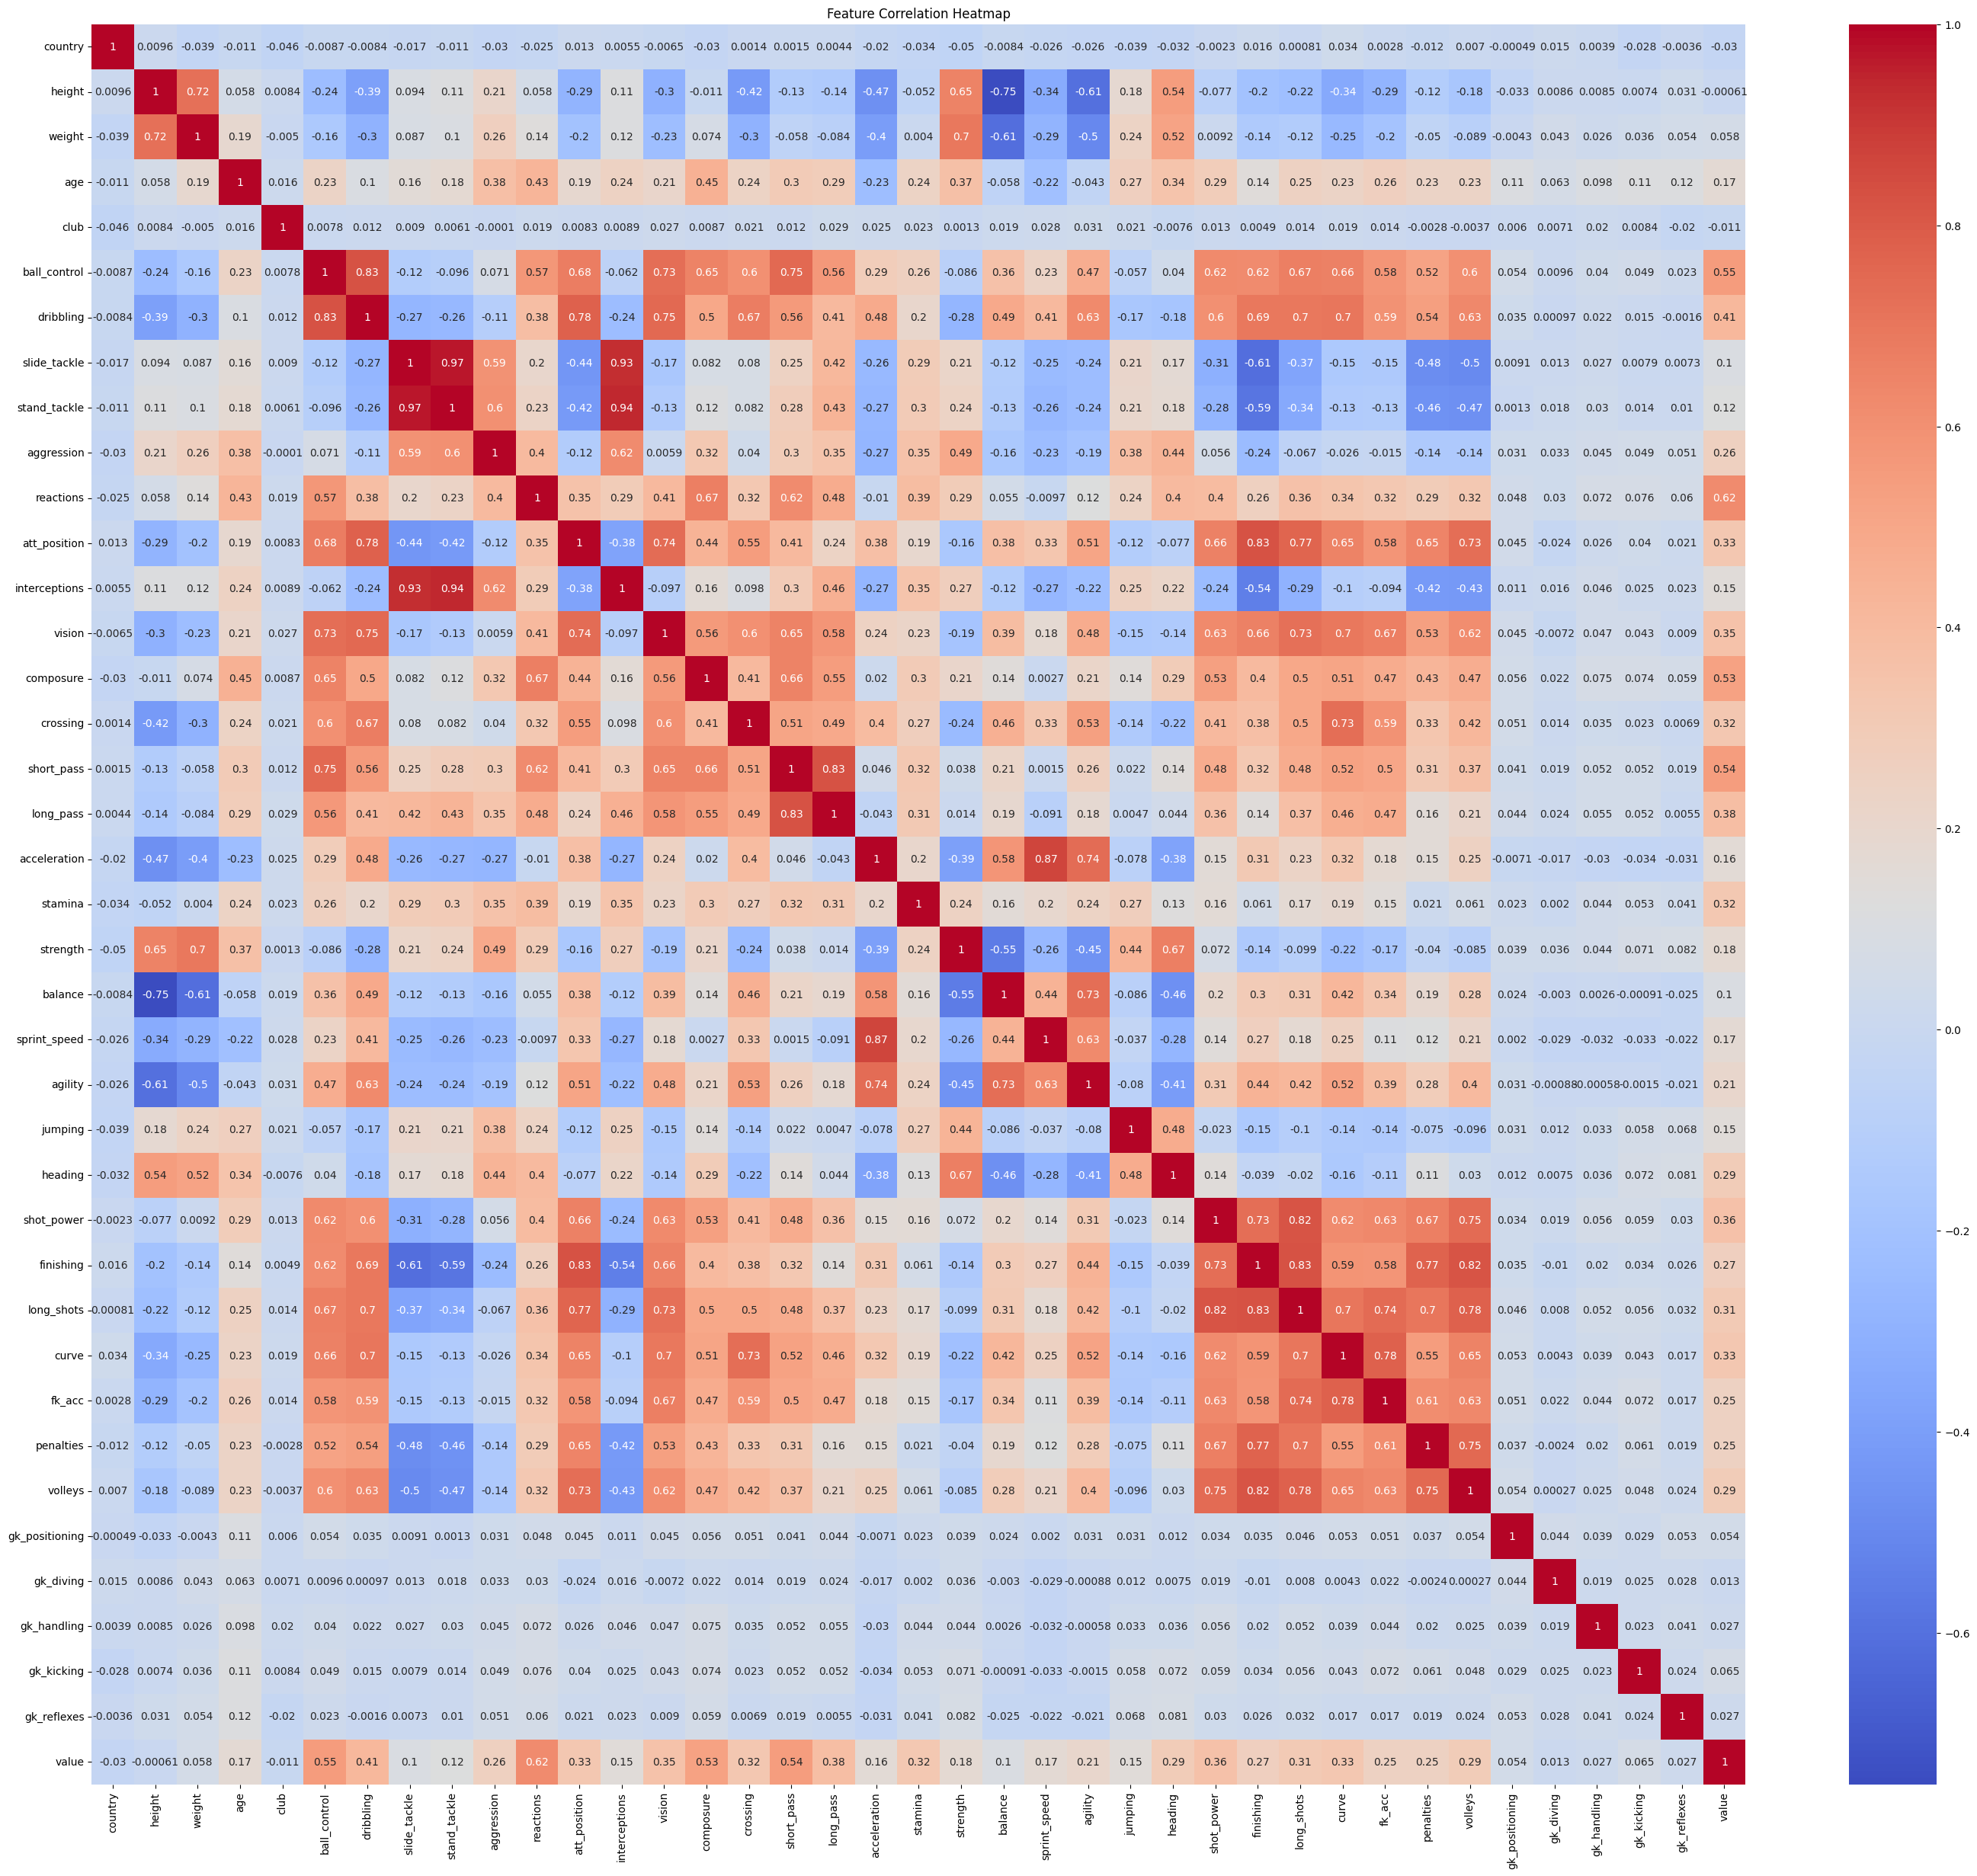

In [33]:
plt.figure(figsize=(35,30))
sns.heatmap(df.corr(),cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")

Technical attributes like reactions, composure, and ball control show strong correlation with player value, while goalkeeper attributes have minimal impact

In [44]:
#split the dataset into x and y
# In the x it will include the everything except the target and the in the y only target variable
X=df.drop('value',axis=1)
y=df['value']


#Standardization

In [45]:
#scale the only on the input data not on all data

from sklearn.preprocessing import StandardScaler


In [46]:
ss = StandardScaler()


In [47]:
X_scaled = ss.fit_transform(X)

In [48]:
X_scaled

array([[-0.98980928,  1.77741062,  1.48436843, ..., -1.45536271,
        -1.10472025, -0.45049873],
       [-1.23678464,  0.02251872,  0.86053942, ...,  1.23932122,
        -0.76771904,  1.21259373],
       [-1.38496986,  0.97973249,  1.79628294, ..., -0.78169173,
         1.2542882 , -0.45049873],
       ...,
       [ 1.65282713, -0.29655253, -0.54307587, ..., -0.10802074,
        -1.77872266,  1.21259373],
       [ 1.23296901, -0.45608816, -0.23116136, ..., -0.78169173,
         0.24328458, -0.11788024],
       [ 1.50464191,  1.29880374,  2.42011196, ..., -0.10802074,
         0.58028579, -0.11788024]])

##Train_test_Split

In [65]:
from sklearn.model_selection import train_test_split

#split into the train_test_spliy


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2)

ML workflow should have 2 parts:

1.first baseline model with default parameters

2.Optimized/refined model using Grid search CV

##Build the machine learning model

In [66]:
#Ml model building

from sklearn.ensemble import RandomForestRegressor


In [67]:
#build the simples version of Random forest classifier and the fine tune it using grid search CV
rf =RandomForestRegressor()

In [68]:
b1_model=rf.fit(X_train,y_train)


In [70]:
#compare y_pread and y_test

y_pred = b1_model.predict(X_test)

In [71]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 348998.3567251462
MSE: 279120302234.1228
RMSE: 528318.3720391737
R2 Score: 0.6705300316827634


##PCA

In [72]:
from sklearn.decomposition import PCA

In [76]:
pca=PCA()

In [77]:
X_pca=pca.fit_transform(X_scaled)

In [78]:
#Explain variance

explained_variance=pca.explained_variance_ratio_

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

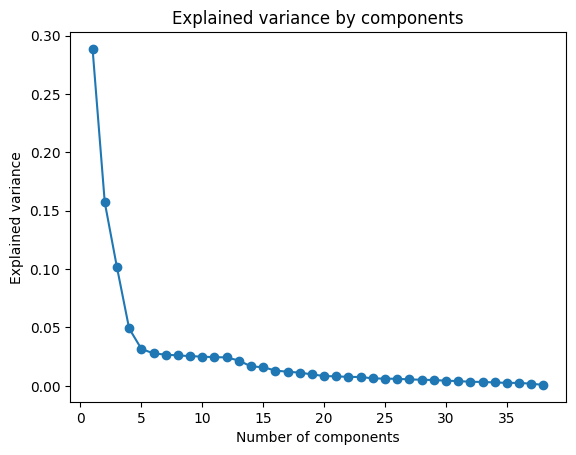

In [79]:
plt.figure()
plt.plot(range(1,len(explained_variance)+1),explained_variance,'o-')
plt.title('Explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

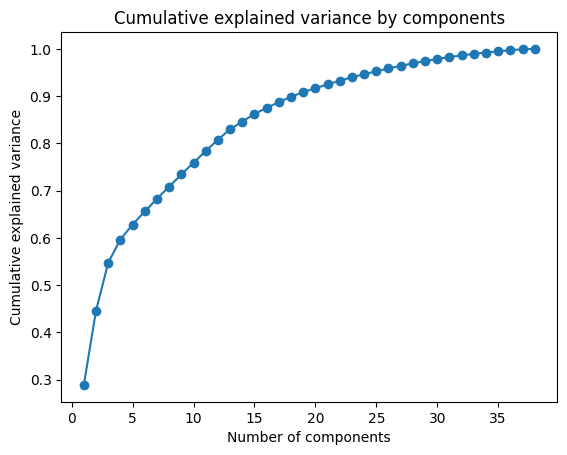

In [80]:
cumulative_variance=np.cumsum(explained_variance)
plt.figure()
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,'o-')
plt.title('Cumulative explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt


In [81]:
#select optimal component

n_components=np.argmax(cumulative_variance>=0.95)+1


In [82]:
n_components

np.int64(25)

In [83]:
#Apply PCA with 25 components
pca=PCA(n_components=25)

#transform the data
X_pca=pca.fit_transform(X_scaled)


In [84]:
X_pca.shape

(4272, 25)

##GridSearch CV

Hyperparameter tunnig technique to find the optimal values of the parameters

In [85]:
#Define the parameters grid randomly as trail and error method
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

In [86]:
#Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [87]:
#Initialize Grid search
from sklearn.model_selection import GridSearchCV

grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5)

In [ ]:
#Train the Gridsearch

grid.fit(X_train,y_train)

In [ ]:
#best parameters

print("Best Params:",grid.best_params_)
print("Best CV Score:",grid.best_score_)


In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("MAE (Best Model):", mean_absolute_error(y_test, y_pred_best))
print("MSE (Best Model):", mean_squared_error(y_test, y_pred_best))
print("RMSE (Best Model):", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score (Best Model):", r2_score(y_test, y_pred_best))